Задание 1. Необходимо построить график зависимости вероятности задержки рейса от количества самолетов в парке компании, а также определить, для какой из крупных авиакомпаний вероятность задержки окажется наибольшей.

Исследование:
1. С помощью библиотеки pandas данные из CSV-файла были загружены в объект DataFrame.
2. Выполнена группировка по авиакомпаниям (carrier) с подсчетом уникальных бортов (tailnum) для каждой.
3. В соответствии с условием, к крупным отнесены 8 компаний, имеющих в парке более 200 самолетов. Остальные исключены из анализа.
4. Вероятность задержки определена как отношение количества рейсов с положительным значением dep_delay к общему числу вылетов каждой компании.
5. С помощью matplotlib построена точечная диаграмма. Компании на графике ранжированы по убыванию количества самолетов. Точки не соединены линиями, так как прямой связи между размером компании и частотой задержек визуально нет. В частности, крупнейшая авиакомпания выборки показала один из самых низких результатов по вероятности задержки.

Итог: Авиакомпанией с наибольшей вероятностью задержки рейса является WN.

(код и график см. ниже)

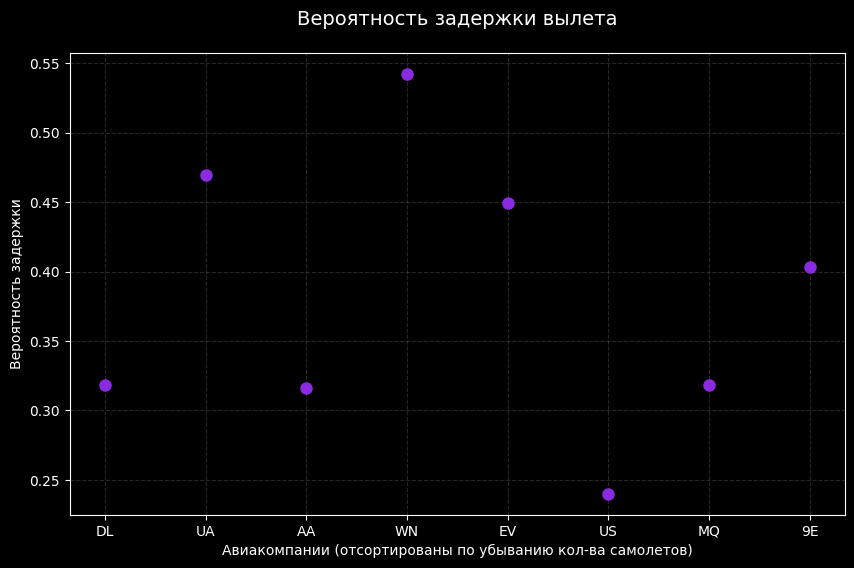

Наибольшая вероятность задержки у компании: WN


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. загрузка файла
df = pd.read_csv('/flights_NY1.csv')

# 2. подсчет количества самолетов для каждой компании
planes_count = df.groupby('carrier')['tailnum'].nunique()

# 3. отбор компаний, у которых больше 200 самолетов
top_carriers = planes_count[planes_count > 200].index

# 4. подсчет вероятности задержки (доля рейсов, где dep_delay > 0)
delay_probs = df[df['carrier'].isin(top_carriers)].groupby('carrier')['dep_delay'].apply(lambda x: (x > 0).mean())

# 5. сортировка компаний по убыванию числа самолетов
sorted_index = planes_count[top_carriers].sort_values(ascending=False).index
plot_data = delay_probs.reindex(sorted_index)

# 6. построение графика
plt.figure(figsize=(10, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.plot(plot_data.index, plot_data.values, 'o', color='blueviolet', markersize=8)

plt.title('Вероятность задержки вылета', color='white', fontsize=14, pad=20)
plt.xlabel('Авиакомпании (отсортированы по убыванию кол-ва самолетов)', color='white', fontsize=10)
plt.ylabel('Вероятность задержки', color='white', fontsize=10)

ax.tick_params(axis='both', colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('white')

plt.grid(True, linestyle='--', alpha=0.3, color='gray')

plt.show()


# ответ
print(f"Наибольшая вероятность задержки у компании: {plot_data.idxmax()}")



Задание 2. Необходимо для каждого самолета найти среднее время, которое он провел в воздухе, построить на основе полученных значений гистограмму и, предполагая что это распределение описывается нормальным законом, оценить параметры нормального закона и наложить график плотности полученного нормального закона на график с гистограммой, а также выяснить, в каких пределах лежит среднее время для 95% всех самолетов.

Исследование:
1. Для каждого уникального самолета (tailnum) было вычислено среднее время нахождения в воздухе (air_time) с помощью mean().
2. На основе полученного набора данных были рассчитаны параметры нормального распределения: математическое ожидание (mu = 157.50) и стандартное отклонение (sigma = 75.80).
3. Построена гистограмма плотности распределения средних времен. Поверх гистограммы наложен график теоретической плотности нормального распределения (кривая Гаусса).
4. Для определения границ 95%-го интервала был использован стандартный статистический коэффициент 1.96, определяющий диапазон наиболее вероятных значений для нормального закона.

Итог: построенный график подтверждает, что данные в целом подчиняются нормальному закону. Наблюдаемая правосторонняя асимметрия объясняется наличием в выборке небольшого количества самолетов, совершающих преимущественно дальние перелеты (выбросы в районе 600 минут).

Ответ: 95% всех самолетов имеют среднее время полета в пределах от 8.92 до 306.07 минут.

(код и график см. ниже)


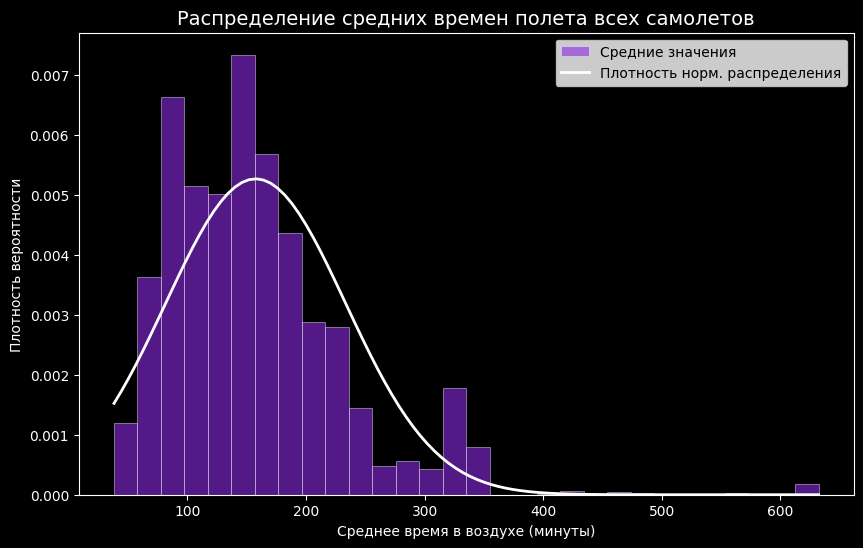

Параметры: mu = 157.50, sigma = 75.80
95% самолетов имеют среднее время полета в пределах: от 8.92 до 306.07 мин.


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# 1. подсчет среднего времени в воздухе для каждого самолета
plane_means = df.groupby('tailnum')['air_time'].mean()

# 2. параметры нормального закона для полученных средних значений
mu = plane_means.mean()   # математическое ожидание
sigma = plane_means.std() # стандартное отклонение

# 3. визуализация
plt.figure(figsize=(10, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# гистограмма средних значений
plt.hist(plane_means, bins=30, density=True, color='blueviolet',
         alpha=0.6, edgecolor='white', linewidth=0.5, label='Средние значения')


# кривая нормального распределения
x = np.linspace(plane_means.min(), plane_means.max(), 100)
plt.plot(x, norm.pdf(x, mu, sigma), color='white', linewidth=2, label='Плотность норм. распределения')

# оформление
plt.title('Распределение средних времен полета всех самолетов', color='white', fontsize=14)
plt.xlabel('Среднее время в воздухе (минуты)', color='white')
plt.ylabel('Плотность вероятности', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('white')
plt.legend()
plt.show()

# расчет 95% интервала
lower_bound = mu - 1.96 * sigma
upper_bound = mu + 1.96 * sigma

print(f"Параметры: mu = {mu:.2f}, sigma = {sigma:.2f}")
print(f"95% самолетов имеют среднее время полета в пределах: от {lower_bound:.2f} до {upper_bound:.2f} мин.")


Задание 3. Необходимо определить, значимо ли различаются распределения средней скорости самолетов между авиакомпаниями WN и UА. Провести статистический тест, а также нарисовать графики распределений, отметить на них средние значения и доверительный интервал с уровнем доверия 0.95 для среднего.

Исследование:

1. Была рассчитана путевая скорость (отношение дистанции ко времени в воздухе, миль/мин).
2. С помощью библиотеки seaborn построены графики плотности (KDE) для обеих компаний. Использование плотности вероятности по оси Y позволило корректно сравнить компании с разным объемом накопленных данных.
3. На графике отмечены средние значения (вертикальные пунктиры) и 95%-е доверительные интервалы (Confidence Intervals, CI). Краткость интервалов объясняется большим объемом выборки, что показывает высокую точность оценки средних.
4. Для подтверждения значимости различий применен T-тест Уэлча (к классическому тесту Стьюдента, взятому из библиотеки scipy было добавлено (equal_var=False), что означает, что тест необходимо провести с разным разбросом данных у двух компаний (equal variation переводится как равное изменение/разброс)). Данный тест был выбран из-за возможности работы с выборками, имеющими разную дисперсию (разброс данных).

Итог: распределение скоростей авиакомпании UA заметно смещено вправо относительно WN.Средняя скорость WN: 6.68 миль/мин.Средняя скорость UA: 7.02 миль/мин. P-value: значение стремится к нулю.

Вывод: Полученное значение P-value ниже критического уровня 0.05, это позволяет сказать, что разница статистически значима: самолеты компании UA в среднем летают быстрее, чем самолеты WN. (доверительные интервалы не накладываются друг на друга)

(код и график см. ниже)


/tmp/ipykernel_16107/917688049.py:35: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(speed_wn, color='blueviolet', shade=True, label='WN', linewidth=2)
/tmp/ipykernel_16107/917688049.py:36: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(speed_ua, color='white', shade=True, label='UA', linewidth=2)


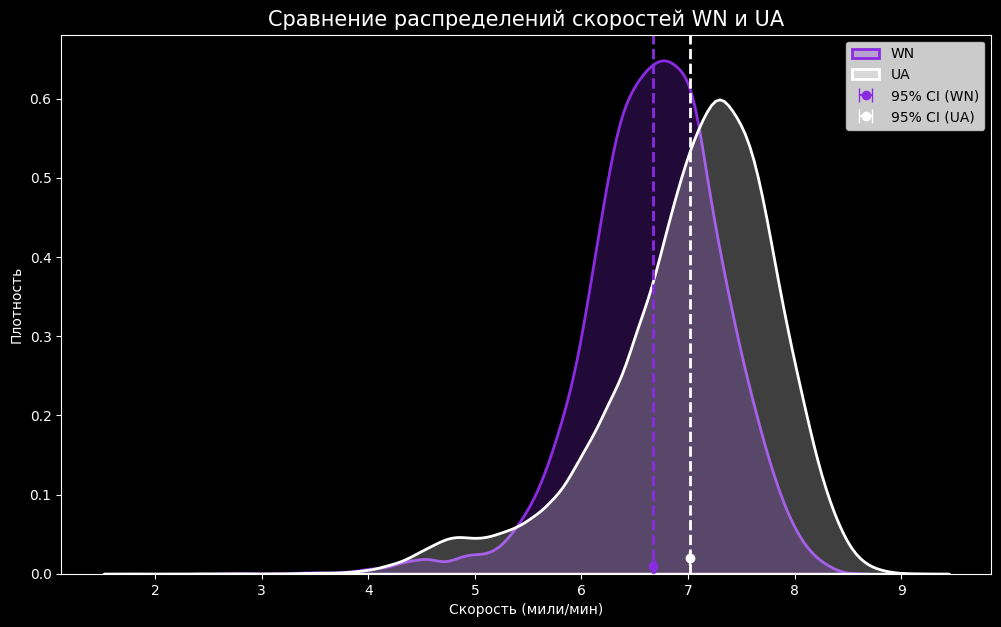

Средняя скорость WN: 6.6755, UA: 7.0147
P-value: 0.00e+00


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# расчет скорости (мили в минуту)
df['speed'] = df['distance'] / df['air_time']

# выборки скоростей для WN и UA
speed_wn = df[df['carrier'] == 'WN']['speed'].dropna()
speed_ua = df[df['carrier'] == 'UA']['speed'].dropna()

# статистический тест (T-тест Уэлча)
t_stat, p_value = stats.ttest_ind(speed_wn, speed_ua, equal_var=False)

# функция для расчета доверительного интервала среднего (95%)
def get_ci(data):
    mean = data.mean()
    sigma = data.std()
    n = len(data)
    margin = 1.96 * (sigma / np.sqrt(n))
    return mean - margin, mean + margin

ci_wn = get_ci(speed_wn)
ci_ua = get_ci(speed_ua)

# визуализация
plt.figure(figsize=(12, 7), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# плавные кривые распределения (KDE)
sns.kdeplot(speed_wn, color='blueviolet', shade=True, label='WN', linewidth=2)
sns.kdeplot(speed_ua, color='white', shade=True, label='UA', linewidth=2)

# Отмечаем средние (вертикальные линии)
plt.axvline(speed_wn.mean(), color='blueviolet', linestyle='--', linewidth=2)
plt.axvline(speed_ua.mean(), color='white', linestyle='--', linewidth=2)

# Рисуем доверительные интервалы (горизонтальные отрезки внизу)
plt.errorbar(speed_wn.mean(), 0.01, xerr=1.96*(speed_wn.std()/np.sqrt(len(speed_wn))),
             fmt='o', color='blueviolet', capsize=5, label='95% CI (WN)')
plt.errorbar(speed_ua.mean(), 0.02, xerr=1.96*(speed_ua.std()/np.sqrt(len(speed_ua))),
             fmt='o', color='white', capsize=5, label='95% CI (UA)')

# Оформление
plt.title('Сравнение распределений скоростей WN и UA', color='white', fontsize=15)
plt.xlabel('Скорость (мили/мин)', color='white')
plt.ylabel('Плотность', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('white')
plt.legend()
plt.show()

print(f"Средняя скорость WN: {speed_wn.mean():.4f}, UA: {speed_ua.mean():.4f}")
print(f"P-value: {p_value:.2e}")


Задание 4. Найти зависимость среднего расстояния, на которое летает самолет, от его средней скорости, используя модель линейной регрессии (при необходимости, использовать полиномиальные признаки и/или другие преобразования признаков). Построить график, содержащий данные и полученную зависимость.

Исследование:
1. С помощью группировки по номерам (tailnum) были вычислены средние показатели скорости и расстояния для каждого самолета.
2. Для реализации модели была использована библиотека Scikit-learn (модуль linear_model - набор инструментов и алгоритмов, предназначенных для решения задач машинного обучения, основанных на линейных зависимостях).
   *   PolynomialFeatures (degree=2) — преобразовал входные данные, добавив квадратичный признак (скорость в квадрате). Это позволило модели учитывать нелинейность зависимости, благодаря чему регрессионная кривая смогла адаптироваться к изгибу данных и точнее их описать.
   *   LinearRegression — на основе данных вычислил коэффициенты уравнения регрессии.
3. С помощью команды .fit() был сделан подбор оптимальных параметров уравнения (y = aX^2 + bX + c). Процесс обучения заключался в минимизации отклонений линии от реальных точек (метод наименьших квадратов).
4. Построен график рассеяния, на который наложена полученная регрессионная кривая. Качество модели оценено через коэффициент детерминации (R^2).

Вывод: исследование выявило сильную статистическую связь (R^2 ~ 0.75) между средней скоростью самолета и среднем расстоянием его полетов. Выбор полинома второй степени оказался оправданным: регрессионная кривая достаточно точно описывает изгиб данных, подтверждая, что на более длинных дистанциях самолеты показывают более высокую среднюю скорость за счет длительного нахождения в крейсерском режиме (режиме постоянной скорости на определенной высоте).

Результаты:
*   Точность модели (R^2): 0.7450.
*   Форма зависимости: Полиномиальная (квадратичная).

(код и график см. ниже)

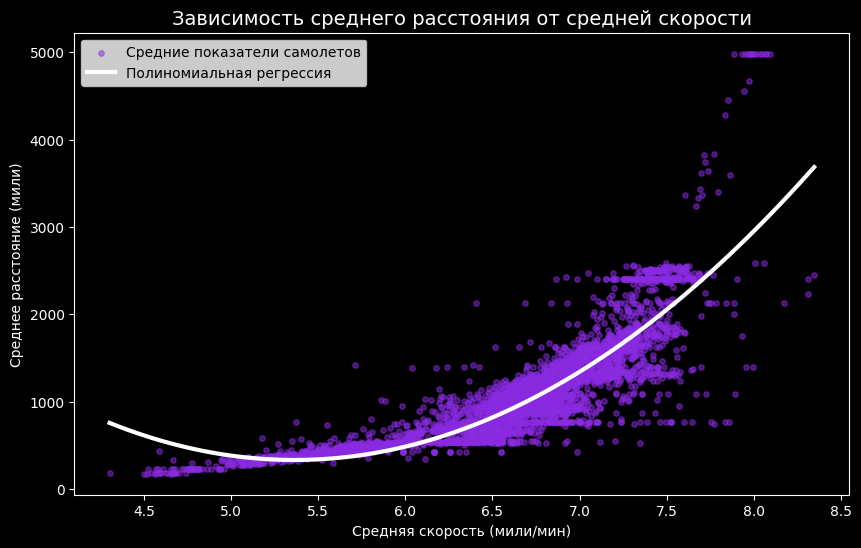

Точность модели (R^2): 0.7450


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# подсчёт средней скорости и среднего расстояния для каждого самолета
df['speed'] = df['distance'] / df['air_time']
plane_stats = df.groupby('tailnum').agg({'speed': 'mean', 'distance': 'mean'}).dropna()

# подготовка данных (X - скорость, y - расстояние)
X = plane_stats['speed'].values.reshape(-1, 1)
y = plane_stats['distance'].values

# создание полиномиальных признаков (степень 2, чтобы линия была плавной кривой)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# обучение модели (подбор оптимальных коэффициентов для уравнения регрессии вида y = a*X^2 + b*X + c)
model = LinearRegression()
model.fit(X_poly, y)

# визуализация
plt.figure(figsize=(10, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# создание облака точек
plt.scatter(X, y, color='blueviolet', alpha=0.5, s=15, label='Средние показатели самолетов')

# построение регрессионой кривой
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_pred = model.predict(poly.transform(X_range))
plt.plot(X_range, y_pred, color='white', linewidth=3, label='Полиномиальная регрессия')

# оформление
plt.title('Зависимость среднего расстояния от средней скорости', color='white', fontsize=14)
plt.xlabel('Средняя скорость (мили/мин)', color='white')
plt.ylabel('Среднее расстояние (мили)', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('white')
plt.legend()
plt.show()

# точность модели
print(f"Точность модели (R^2): {model.score(X_poly, y):.4f}")


Задание 5. Необходимо разделить самолеты на группы на основе значения их средних скоростей и количества рейсов за год.

Исследование:
1. Для каждого борта вычислены два показателя: средняя путевая скорость и суммарное количество выполненных рейсов за год.
2. Поскольку данные в условии признаки имеют разные единицы измерения (скорость — единицы, рейсы — сотни), было применено масштабирование (StandardScaler). Это «уравняло» значимость обоих параметров для алгоритма.
3. Для анализа использован метод K-means (K-средних) из библиотеки Scikit-learn. Число кластеров (n_clusters=3) выбрано равным 3 (из предположения о разделении рейсов на три основыне категории: ближнего, среднего и дальнего полета; на большее число категорий делить самолеты неразумно, так как кластеры будут неразличимы друг от друга)
4. Построена диаграмма рассеяния. Использование масштабирования позволило учесть оба признака и получить не прямолинейные границы между группами.

Интерпретация кластеров:

*   Синий кластер. Самолеты с невысокой скоростью и малым количеством рейсов. Вероятно, старые модели, работающие на коротких маршрутах.
*   Розовый кластер. Самолеты с высокой скоростью, но умеренным количеством рейсов. Это быстрые самолеты для дальних дистанций, поэтому они не успевают совершить много взлетов-посадок за день (количество рейсов за год невелико).
*   Желтый кластер. Самые активные самолеты. Они имеют достаточно широкий диапазон скоростей (но при этом не самые минимальный и самые максимальные из возможных) и максимальное количество рейсов. Это основа авиакомпаний, которая постоянно находится в воздухе на маршрутах средней дальности.

Итог: метод кластерного анализа показал внутреннюю структуру авиапарка, разделив самолеты по их средней скорости полета и количеству рейсов в год (интенсивности использования).

(код и график см. ниже)



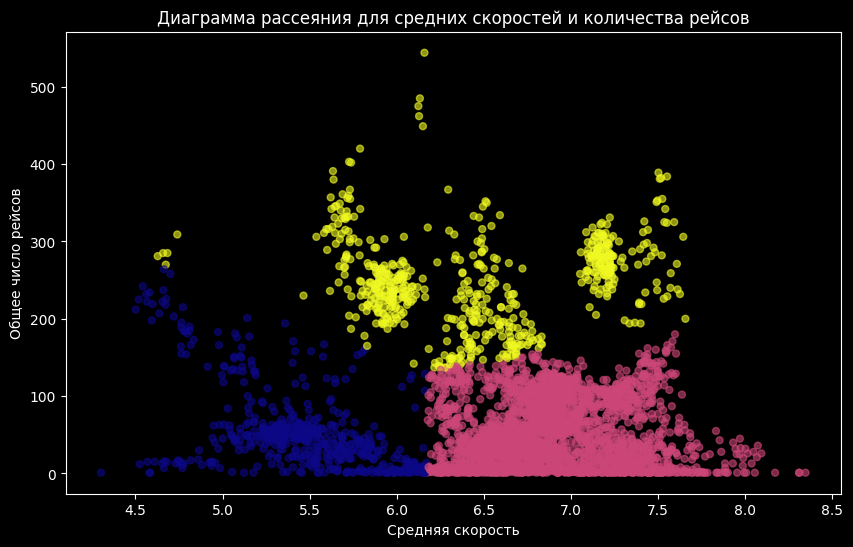

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# подготовка данных (сопоставление средней скорости и количества рейсов за год для каждого самолета)
plane_stats = df.groupby('tailnum').agg({'speed': 'mean', 'year': 'count'}).dropna()
plane_stats.columns = ['avg_speed', 'total_flights']

# масштабирование (чтобы скорость и количество рейсов стали "равноправными")
scaler = StandardScaler()
data_scaled = scaler.fit_transform(plane_stats)

# обучение KMeans на масштабированных данных
kmeans = KMeans(n_clusters=3, random_state=2)
plane_stats['cluster'] = kmeans.fit_predict(data_scaled)

# визуализация
plt.figure(figsize=(10, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.scatter(plane_stats['avg_speed'], plane_stats['total_flights'],
            c=plane_stats['cluster'], cmap='plasma', s=25, alpha=0.6)

# оформление
plt.title('Диаграмма рассеяния для средних скоростей и количества рейсов', color='white')
plt.xlabel('Средняя скорость', color='white')
plt.ylabel('Общее число рейсов', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('white')
plt.show()

